   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.1/218.1 kB 4.9 MB/s eta 0:00:00
Mounted at /content/drive
Generated 10000 state vectors successfully.
Residual shape: (10000, 3)
X shape: (9970, 30, 3), Y shape: (9970, 3)
Model and scalers successfully loaded from Google Drive.
X_train shape: (7976, 30, 3)
Y_train shape: (7976, 3)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 30, 128)        │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,171 (465.51 KB)

 Trainable params: 119,171 (465.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/32
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - loss: 0.0255 - mae: 0.0877 - val_loss: 0.0261 - val_mae: 0.0939
Epoch 2/32
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - loss: 0.0254 - mae: 0.0858 - val_loss: 0.0259 - val_mae: 0.0900
Epoch 3/32
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - loss: 0.0254 - mae: 0.0861 - val_loss: 0.0265 - val_mae: 0.0969
Epoch 4/32
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0253 - mae: 0.0861 - val_loss: 0.0268 - val_mae: 0.1010
Epoch 5/32
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - loss: 0.0253 - mae: 0.0862 - val_loss: 0.0260 - val_mae: 0.0929
Epoch 6/32
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0254 - mae: 0.0864 - val_loss: 0.0263 - val_mae: 0.0941
Epoch 7/32
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0254 - mae: 0.0864 - val_loss: 0.0264 - val_mae: 0.0927
Epoch 8/32
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.0253 - mae: 0.0861 - val_loss: 0.0264 - val_mae: 0.0955
Epoch 9/32
125/125 ━━━━━━━━━━━━━━━━━

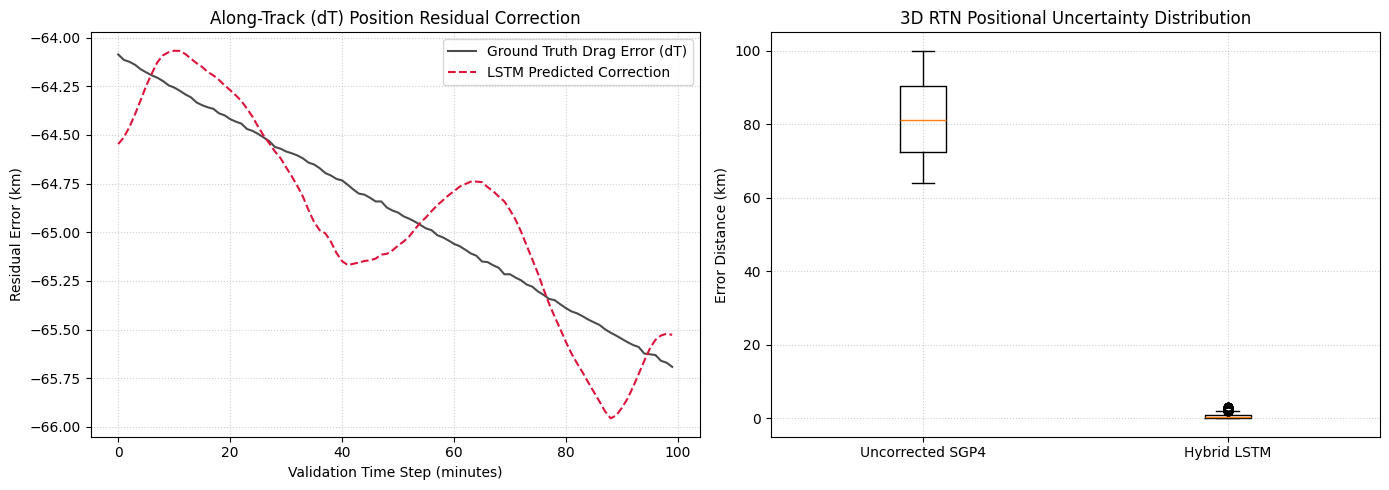

Batch transformation shape: (10000, 3)
Maximum norm deviation between ECI and RTN: 4.3e-14 km
All assets successfully saved to: /content/drive/MyDrive/SGP4_LSTM_Debris_Project


In [1]:
!pip install sgp4
import numpy as np
import random as rd
import pandas as pd
from datetime import datetime, timedelta
from google.colab import drive
from sgp4.api import Satrec, jday
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import joblib
import os

drive.mount('/content/drive')

line1 = "1 25544U 98067A   24050.52153201  .00014728  00000-0  26352-3 0  9993"
line2 = "2 25544  51.6416 261.2381 0004860 183.1852 248.8719 15.49551474440091"

sat = Satrec.twoline2rv(line1, line2)

r_list = []
v_list = []
dr_list = []

steps = 10000
start_date = datetime(2026, 9, 11, 0, 0, 0)

for step in range(steps):
    current_time = start_date + timedelta(minutes=step)
    jd, fr = jday(current_time.year, current_time.month, current_time.day,
                  current_time.hour, current_time.minute, current_time.second)

    # SGP4 Propagation
    e, position, velocity = sat.sgp4(jd, fr)

    if e != 0:
        continue  # Skip if SGP4 returns an orbital propagation error code

    r_eci = np.array(position)   # [x, y, z] in km
    v_eci = np.array(velocity)   # [vx, vy, vz] in km/s

    # Simulate Ground Truth with quadratic atmospheric drag drift along velocity direction
    v_unit = v_eci / np.linalg.norm(v_eci)

    # Drag causes quadratic decay along velocity vector + small Gaussian measurement noise
    drag_drift = -1e-6 * (step ** 2) * v_unit
    measurement_noise = np.random.normal(0, 0.005, size=3)  # ~5m noise

    r_truth = r_eci + drag_drift + measurement_noise

    # Compute 3D ECI residual [dx, dy, dz]
    dr_eci = r_truth - r_eci

    # Append to storage lists
    r_list.append(r_eci)
    v_list.append(v_eci)
    dr_list.append(dr_eci)

# Convert lists to (N, 3) numpy arrays
r_arr = np.array(r_list)
v_arr = np.array(v_list)
dr_arr = np.array(dr_list)

print(f"Generated {r_arr.shape[0]} state vectors successfully.")
print(f"Residual shape: {dr_arr.shape}")

# Transform ECI coordinates into RTN coordinate system
def rtn(r_eci, v_eci, dr_eci):
    norm_r = np.linalg.norm(r_eci, axis=1, keepdims=True)
    u_R = r_eci / norm_r

    h = np.cross(r_eci, v_eci, axis=1)
    norm_h = np.linalg.norm(h, axis=1, keepdims=True)
    u_N = h / norm_h

    u_T = np.cross(u_N, u_R, axis=1)

    dR = np.sum(dr_eci * u_R, axis=1, keepdims=True)
    dN = np.sum(dr_eci * u_N, axis=1, keepdims=True)
    dT = np.sum(dr_eci * u_T, axis=1, keepdims=True)

    dr_rtn = np.hstack([dR, dT, dN])
    return dr_rtn

dr_rtn = rtn(r_arr, v_arr, dr_arr)

# Create sequence sliding windows
def create_sliding_sequences(data, look_back=30):
    X_list = []
    Y_list = []
    for i in range(len(data) - look_back):
        X_list.append(data[i:i + look_back])
        Y_list.append(data[i + look_back])
    return np.array(X_list), np.array(Y_list)

X, Y = create_sliding_sequences(dr_rtn, look_back=30)
print(f"X shape: {X.shape}, Y shape: {Y.shape}")

# Split raw data before scaling to avoid data leakage
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle=False
)

# Load existing model and scalers if available
save_dir = '/content/drive/MyDrive/SGP4_LSTM_Debris_Project'
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, 'sgp4_lstm_model.keras')
scaler_x_path = os.path.join(save_dir, 'scaler_x.pkl')
scaler_y_path = os.path.join(save_dir, 'scaler_y.pkl')

resume_training = True
model = None
scaler_x = None
scaler_y = None

if resume_training and os.path.exists(model_path):
    try:
        model = keras.models.load_model(model_path)
        scaler_x = joblib.load(scaler_x_path)
        scaler_y = joblib.load(scaler_y_path)
        print("Model and scalers successfully loaded from Google Drive.")
    except Exception as e:
        print(f"Failed to load checkpoint: {e}. Building a new model.")
        model = None

# Scale features correctly based on load state
if scaler_x is None or scaler_y is None:
    scaler_x = MinMaxScaler(feature_range=(-1, 1))
    scaler_y = MinMaxScaler(feature_range=(-1, 1))

    samples_tr, time_steps, features = X_train_raw.shape
    X_train = scaler_x.fit_transform(X_train_raw.reshape(-1, features)).reshape(samples_tr, time_steps, features)
    Y_train = scaler_y.fit_transform(Y_train_raw)
else:
    samples_tr, time_steps, features = X_train_raw.shape
    X_train = scaler_x.transform(X_train_raw.reshape(-1, features)).reshape(samples_tr, time_steps, features)
    Y_train = scaler_y.transform(Y_train_raw)

# Scale test partition using fitted scalers
samples_te, time_steps, features = X_test_raw.shape
X_test = scaler_x.transform(X_test_raw.reshape(-1, features)).reshape(samples_te, time_steps, features)
Y_test = scaler_y.transform(Y_test_raw)

print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")

def build_model(input_shape):
    model = keras.Sequential([
        keras.Input(shape=input_shape),
        keras.layers.LSTM(128, return_sequences=True),
        Dropout(0.05),
        LSTM(64, return_sequences=False),
        Dense(32, activation='tanh'),
        Dense(3, activation='linear')
    ])
    return model

if model is None:
    model = build_model(input_shape=(X_train.shape[1], X_train.shape[2]))
    print("New model instantiated.")

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=32,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Inverse Scaling
Y_pred_scaled = model.predict(X_test)

# Convert from scaled [-1, 1] range back to physical kilometers
Y_test_km = scaler_y.inverse_transform(Y_test)
Y_pred_km = scaler_y.inverse_transform(Y_pred_scaled)

# Reduce phase jitter in plot visualization
Y_pred_km_smoothed = pd.DataFrame(Y_pred_km).ewm(span=2).mean().to_numpy()

# Calculate 3D RMSE
rmse_sgp4 = np.sqrt(np.mean(np.sum(Y_test_km**2, axis=1)))
rmse_hybrid = np.sqrt(np.mean(np.sum((Y_test_km - Y_pred_km)**2, axis=1)))
improvement = ((rmse_sgp4 - rmse_hybrid) / rmse_sgp4) * 100

print(f"\nUncorrected SGP4 3D RMSE: {rmse_sgp4:.4f} km")
print(f"Hybrid SGP4+LSTM 3D RMSE: {rmse_hybrid:.4f} km")
print(f"Total Positional Error Reduction: {improvement:.2f}%")

# Visualizing Along-Track (dT) Correction
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(Y_test_km[:100, 1], label='Ground Truth Drag Error (dT)', color='black', alpha=0.7)
plt.plot(Y_pred_km_smoothed[:100, 1], label='LSTM Predicted Correction', color='crimson', linestyle='--')
plt.title('Along-Track (dT) Position Residual Correction', fontsize=12)
plt.xlabel('Validation Time Step (minutes)', fontsize=10)
plt.ylabel('Residual Error (km)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
err_sgp4_3d = np.linalg.norm(Y_test_km, axis=1)
err_hybrid_3d = np.linalg.norm(Y_test_km - Y_pred_km, axis=1)

plt.boxplot([err_sgp4_3d, err_hybrid_3d], tick_labels=['Uncorrected SGP4', 'Hybrid LSTM'])
plt.title('3D RTN Positional Uncertainty Distribution', fontsize=12)
plt.ylabel('Error Distance (km)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Verify vector magnitude conservation between ECI and RTN
eci_lengths = np.linalg.norm(dr_arr, axis=1)
rtn_lengths = np.linalg.norm(dr_rtn, axis=1)
max_length_diff = np.max(np.abs(eci_lengths - rtn_lengths))

print(f"Batch transformation shape: {dr_rtn.shape}")
print(f"Maximum norm deviation between ECI and RTN: {max_length_diff:.1e} km")

# Save model and scalers to Google Drive
model.save(model_path)
joblib.dump(scaler_x, scaler_x_path)
joblib.dump(scaler_y, scaler_y_path)

print(f"All assets successfully saved to: {save_dir}")